# Experiments on rice dataset

In [22]:
import sys
from pathlib import Path

# Add parent directory to path to import lazyfca and utils
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA
from utils import estimate_quality

In [23]:
pd.set_option('display.max_columns', None)

In [24]:
data = pd.read_csv("../datasets/rice.csv")
data

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


In [25]:
data.Class.value_counts()

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

In [26]:
data['Class'] = data['Class'].map({'Osmancik': 0, 'Cammeo': 1})
data

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,1
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,1
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,1
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,1
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,1
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,0
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,0
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,0
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,0


In [27]:
data.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934,0.427822
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239,0.494828
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413,0.000000
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862,0.000000
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361,0.000000
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562,1.000000
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050,1.000000


In [28]:
data.to_csv("../datasets/rice_pr.csv", index=False)

In [17]:
X = data.drop(columns = ["Class"])
y = data["Class"].to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = X.columns
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pd.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pd.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [29]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=1,
        supporter_opposer_ratio=1.0,
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=2,
        supporter_opposer_ratio=1.7,
    ),
    pos_weight=1.0
)
classifier.fit(X_train, y_train)

In [19]:
y_pred = classifier.predict(X_test)

100%|██████████| 381/381 [00:23<00:00, 16.50it/s]


In [20]:
base_metrics = estimate_quality(y_pred, y_test)
base_metrics

{'Accuracy': 0.9212598425196851,
 'Precision': 0.965034965034965,
 'Recall': 0.8466257668711656,
 'AUC-ROC': 0.9813136714132944,
 'F1-score': 0.9019607843137255,
 'True Positive': np.int64(138),
 'True Negative': np.int64(213),
 'False Positive': np.int64(5),
 'False Negative': np.int64(25),
 'True Negative Rate (Specificity)': np.float64(0.9770642201834863),
 'Negative Predictive Value': np.float64(0.8949579831932774),
 'False Positive Rate': np.float64(0.022935779816513763),
 'False Discovery Rate': np.float64(0.03496503496503497)}

## Compare to catboost

In [10]:
import catboost
cb = catboost.CatBoostClassifier(n_estimators=2500, verbose=False)
cb.fit(X_train, y_train)
estimate_quality(cb.predict_proba(X_test), y_test)

{'Accuracy': 0.9212598425196851,
 'Precision': 0.8982035928143712,
 'Recall': 0.9202453987730062,
 'AUC-ROC': 0.9770923622446108,
 'F1-score': 0.9090909090909091,
 'True Positive': np.int64(150),
 'True Negative': np.int64(201),
 'False Positive': np.int64(17),
 'False Negative': np.int64(13),
 'True Negative Rate (Specificity)': np.float64(0.9220183486238532),
 'Negative Predictive Value': np.float64(0.9392523364485982),
 'False Positive Rate': np.float64(0.0779816513761468),
 'False Discovery Rate': np.float64(0.10179640718562874)}

## Thresholds for metrics

In [10]:
score = classifier.explain_sample(X_test.iloc[52]).display()

In [11]:
score[score['Type'] == 'POSITIVE'].sort_values(by = 'WRAcc', ascending = False)

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test,Interval tightness,Description volume,Simplicity prior,Query binary similarity,Query numeric similarity,Query similarity,Query weighted precision,Query weighted WRAcc,Stability,Robustness,Delta stability
120,"[12433.0, 15306.0]; [442.48199462890625, 524.6...",POSITIVE,1467,1962,286,71,4.028169,0.194956,0.036188,0.801120,1.872558,0.038865,0.158768,0.158768,0.257207,0.048934,0.032388,4.006993,226.847409,232.612716,0.650437,3.234882e-04,0.740981,1.0,0.650437,0.650437,0.521079,0.025279,0.007812,0.007812,1.0
224,"[12433.0, 14944.0]; [442.48199462890625, 512.1...",POSITIVE,1467,1962,333,138,2.413043,0.226994,0.070336,0.707006,1.652573,0.038348,0.156657,0.156657,0.225168,0.036594,0.024822,2.407942,173.852028,173.952001,0.635786,4.441054e-04,0.733023,1.0,0.635786,0.635786,0.449504,0.024381,0.007812,0.007812,1.0
452,"[12433.0, 14294.0]; [442.48199462890625, 514.4...",POSITIVE,1467,1962,284,106,2.679245,0.193592,0.054027,0.728205,1.702124,0.034164,0.139566,0.139566,0.217493,0.034269,0.023159,2.671362,162.203305,162.901403,0.662766,2.439508e-04,0.747813,1.0,0.662766,0.662766,0.482630,0.022643,0.007812,0.007812,1.0
296,"[12433.0, 14359.0]; [442.48199462890625, 506.0...",POSITIVE,1467,1962,273,103,2.650485,0.186094,0.052497,0.726064,1.697119,0.032703,0.133597,0.133597,0.211545,0.032403,0.021909,2.642512,153.452116,154.031480,0.689655,1.413286e-04,0.763158,1.0,0.689655,0.689655,0.500733,0.022554,0.007812,0.007812,1.0
613,"[12433.0, 14709.0]; [442.48199462890625, 515.8...",POSITIVE,1467,1962,249,85,2.929412,0.169734,0.043323,0.745509,1.742570,0.030944,0.126411,0.126411,0.210934,0.032357,0.021783,2.918129,152.566540,153.812345,0.684107,1.650073e-04,0.759940,1.0,0.684107,0.684107,0.510008,0.021169,0.007812,0.007812,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,"[12333.0, 12433.0]; [442.48199462890625, 463.1...",POSITIVE,1467,1962,1,1,1.000000,0.000682,0.000510,0.500000,1.168712,0.000042,0.000172,0.000172,0.003524,0.000009,0.000006,1.000000,0.042590,0.042143,0.843992,1.249218e-08,0.865046,1.0,0.843992,0.843992,0.421996,0.000036,0.003906,0.003906,1.0
273,"[12433.0, 12491.0]; [442.48199462890625, 457.1...",POSITIVE,1467,1962,1,1,1.000000,0.000682,0.000510,0.500000,1.168712,0.000042,0.000172,0.000172,0.003524,0.000009,0.000006,1.000000,0.042590,0.042143,0.817318,1.150822e-08,0.845536,1.0,0.817318,0.817318,0.408659,0.000034,0.003906,0.003906,1.0
332,"[12433.0, 12720.0]; [442.48199462890625, 449.6...",POSITIVE,1467,1962,1,1,1.000000,0.000682,0.000510,0.500000,1.168712,0.000042,0.000172,0.000172,0.003524,0.000009,0.000006,1.000000,0.042590,0.042143,0.925373,1.898697e-10,0.930556,1.0,0.925373,0.925373,0.462687,0.000039,0.003906,0.003906,1.0
539,"[12433.0, 13777.0]; [442.48199462890625, 480.8...",POSITIVE,1467,1962,1,1,1.000000,0.000682,0.000510,0.500000,1.168712,0.000042,0.000172,0.000172,0.003524,0.000009,0.000006,1.000000,0.042590,0.042143,0.853028,9.526026e-08,0.871861,1.0,0.853028,0.853028,0.426514,0.000036,0.003906,0.003906,1.0


In [13]:
score[score['Type'] == 'NEGATIVE'].sort_values(by = 'WRAcc', ascending = False)

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
2090,"[9544.0, 12433.0]; [386.56298828125, 442.48199...",NEGATIVE,1962,1467,362,0,inf,0.184506,0.000000,1.000000,1.747706,0.045165,0.184506,0.184506,0.297073,0.311828,-0.034042,725.000000,1304.791030,-1223.614610
1909,"[9584.0, 12433.0]; [390.0039978027344, 442.481...",NEGATIVE,1962,1467,352,0,inf,0.179409,0.000000,1.000000,1.747706,0.043918,0.179409,0.179409,0.292464,0.308240,-0.032188,705.000000,1321.151886,-1209.534279
2076,"[9733.0, 12433.0]; [396.6539916992187, 442.481...",NEGATIVE,1962,1467,336,0,inf,0.171254,0.000000,1.000000,1.747706,0.041921,0.171254,0.171254,0.285000,0.302196,-0.029328,673.000000,1347.541284,-1185.816899
1092,"[8499.0, 12433.0]; [370.4460144042969, 442.481...",NEGATIVE,1962,1467,322,0,inf,0.164118,0.000000,1.000000,1.747706,0.040175,0.164118,0.164118,0.278370,0.296589,-0.026935,645.000000,1370.846075,-1163.816253
1658,"[7833.0, 12433.0]; [373.1570129394531, 442.481...",NEGATIVE,1962,1467,313,0,inf,0.159531,0.000000,1.000000,1.747706,0.039052,0.159531,0.159531,0.274056,0.292822,-0.025450,627.000000,1385.933231,-1149.033297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2138,"[12433.0, 12826.0]; [442.48199462890625, 452.8...",NEGATIVE,1962,1467,3,1,3.0,0.001529,0.000682,0.750000,1.310780,0.000207,0.000847,0.000847,0.012283,0.010594,0.001361,2.333333,1956.005269,-40.897962
2250,"[12433.0, 12571.0]; [442.48199462890625, 453.3...",NEGATIVE,1962,1467,3,1,3.0,0.001529,0.000682,0.750000,1.310780,0.000207,0.000847,0.000847,0.012283,0.010594,0.001361,2.333333,1956.005269,-40.897962
744,"[12433.0, 12695.0]; [442.48199462890625, 447.8...",NEGATIVE,1962,1467,2,1,2.0,0.001019,0.000682,0.666667,1.165138,0.000083,0.000338,0.000338,0.005651,0.007703,0.001362,1.666667,1958.002720,-29.553608
1366,"[12433.0, 12599.0]; [442.48199462890625, 450.2...",NEGATIVE,1962,1467,2,1,2.0,0.001019,0.000682,0.666667,1.165138,0.000083,0.000338,0.000338,0.005651,0.007703,0.001362,1.666667,1958.002720,-29.553608


In [15]:
def plot_f1_vs_metric_threshold(metric_name='wracc', n_points=20, 
                                 pos_supporters=1, pos_ratio=1.0,
                                 neg_supporters=2, neg_ratio=1.7,
                                 sample_idx=52):
    """
    Построить график зависимости F1 score от порога метрики с количеством классификаторов.
    
    Parameters:
    -----------
    metric_name : str
        Название метрики для подбора порога ('wracc', 'matthews_correlation', 'lift', и т.д.)
    n_points : int
        Количество точек на графике
    pos_supporters : int
        Минимальное число supporters для положительных классификаторов
    pos_ratio : float
        Минимальное отношение supporters/opposers для положительных классификаторов
    neg_supporters : int
        Минимальное число supporters для отрицательных классификаторов
    neg_ratio : float
        Минимальное отношение supporters/opposers для отрицательных классификаторов
    sample_idx : int
        Индекс образца для объяснения (для подсчета классификаторов)
    """
    
    # Mapping metric names to score dataframe columns
    metric_column_map = {
        'wracc': 'WRAcc',
        'matthews_correlation': 'Matthews correlation',
        'lift': 'Lift',
        'precision': 'Precision',
        'support': 'Support',
        'error_rate': 'Error rate',
        'balanced_precision_proxy': 'Balanced precision proxy',
        'youdens_j': "Youden's J",
        'information_gain': 'Information gain',
        'gini_gain': 'Gini gain',
        'log_odds_ratio': 'Log odds ratio',
        'chi_squared': 'Chi squared',
        'g_test': 'G-test',
        'supporter_opposer_ratio': 'Supporters to opposers ratio',
    }
    
    column_name = metric_column_map.get(metric_name, metric_name)
    
    # Get range of metric values from the score dataframe
    metric_values = score[column_name].values
    metric_min = metric_values.min()
    metric_max = metric_values.max()
    
    # Create threshold values to test
    thresholds = np.linspace(metric_min, metric_max, n_points)
    
    f1_scores = []
    pos_classifiers_counts = []
    neg_classifiers_counts = []
    
    for threshold in thresholds:
        # Create classifier with metric threshold
        pos_params = LazyFCA.Params(
            supporters_covered=pos_supporters,
            supporter_opposer_ratio=pos_ratio,
        )
        neg_params = LazyFCA.Params(
            supporters_covered=neg_supporters,
            supporter_opposer_ratio=neg_ratio,
        )
        
        # Set the threshold for the specified metric
        setattr(pos_params, metric_name, threshold)
        # setattr(neg_params, metric_name, threshold)
        
        clf = LazyFCA(
            pos_params=pos_params,
            neg_params=neg_params,
            pos_weight=1.0
        )
        clf.fit(X_train, y_train)
        
        # Make predictions
        y_pred = clf.predict(X_test)
        
        # Calculate F1 score
        metrics = estimate_quality(y_pred, y_test)
        f1_scores.append(metrics['F1-score'])
        
        # Get explanation for a sample to count classifiers
        explanation = clf.explain_sample(X_test.iloc[sample_idx])
        score_df = explanation.display()
        
        # Count positive and negative classifiers
        pos_count = len(score_df[score_df['Type'] == 'POSITIVE'])
        neg_count = len(score_df[score_df['Type'] == 'NEGATIVE'])
        
        pos_classifiers_counts.append(pos_count)
        neg_classifiers_counts.append(neg_count)
    
    # Create plot
    plt.figure(figsize=(14, 8))
    plt.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=6, color='blue')
    
    # Add annotations for each point
    for i, (x, y) in enumerate(zip(thresholds, f1_scores)):
        # Positive classifiers count (green) above the point
        plt.annotate(f'{pos_classifiers_counts[i]}', 
                    xy=(x, y), 
                    xytext=(0, 12),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    color='green',
                    weight='bold')
        
        # Negative classifiers count (red) below the point
        plt.annotate(f'{neg_classifiers_counts[i]}', 
                    xy=(x, y), 
                    xytext=(0, -18),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    color='red',
                    weight='bold')
    
    plt.xlabel(f'{column_name} Threshold', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title(f'F1 Score vs {column_name} Threshold\n(Green = Positive Classifiers, Red = Negative Classifiers)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Show best threshold
    best_idx = np.argmax(f1_scores)
    print(f"\nBest {column_name} threshold: {thresholds[best_idx]:.6f}")
    print(f"Best F1 score: {f1_scores[best_idx]:.6f}")
    print(f"Positive classifiers at best threshold: {pos_classifiers_counts[best_idx]}")
    print(f"Negative classifiers at best threshold: {neg_classifiers_counts[best_idx]}")
    
    return thresholds, f1_scores, pos_classifiers_counts, neg_classifiers_counts

In [21]:
N_POINTS = 30

100%|██████████| 381/381 [00:12<00:00, 29.34it/s]


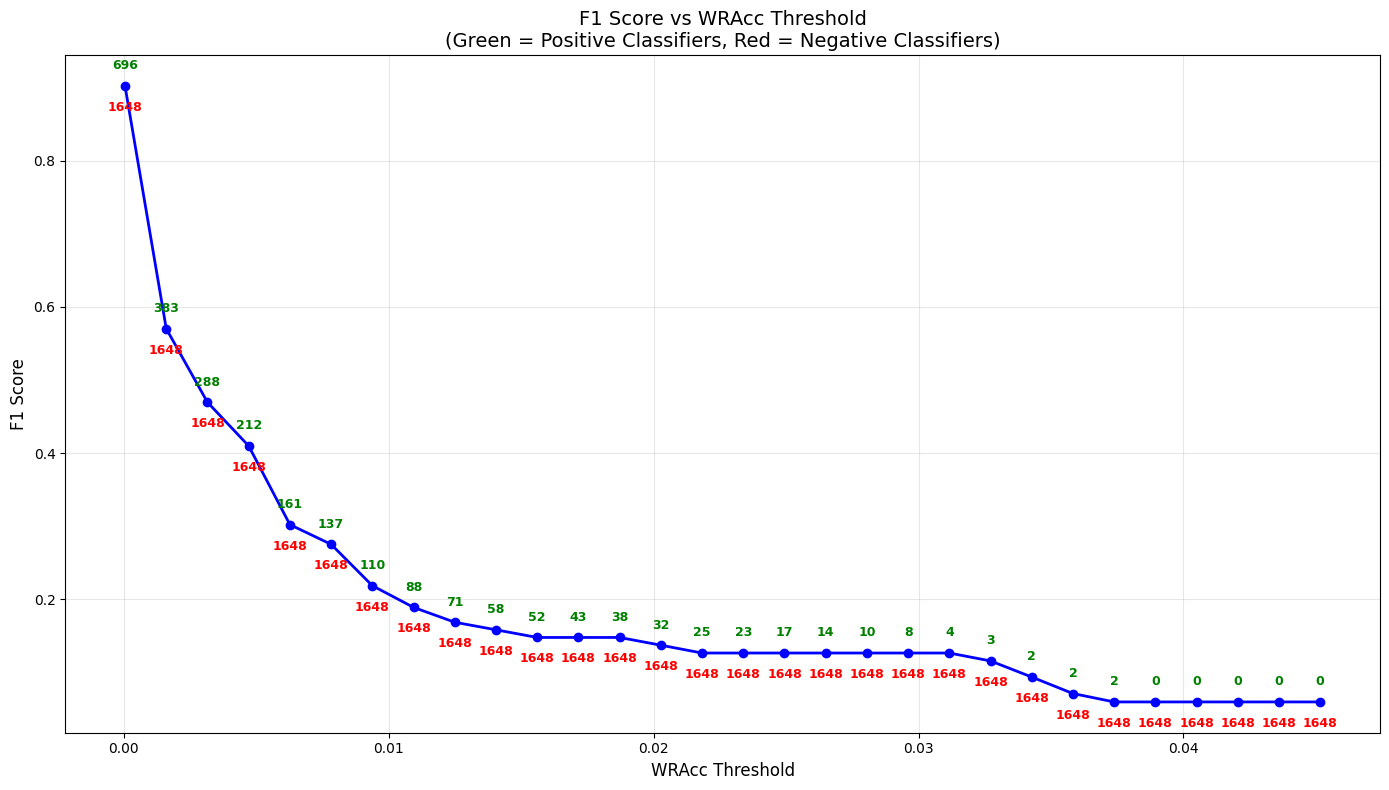


Best WRAcc threshold: 0.000042
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [22]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='wracc',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:10<00:00, 37.04it/s]


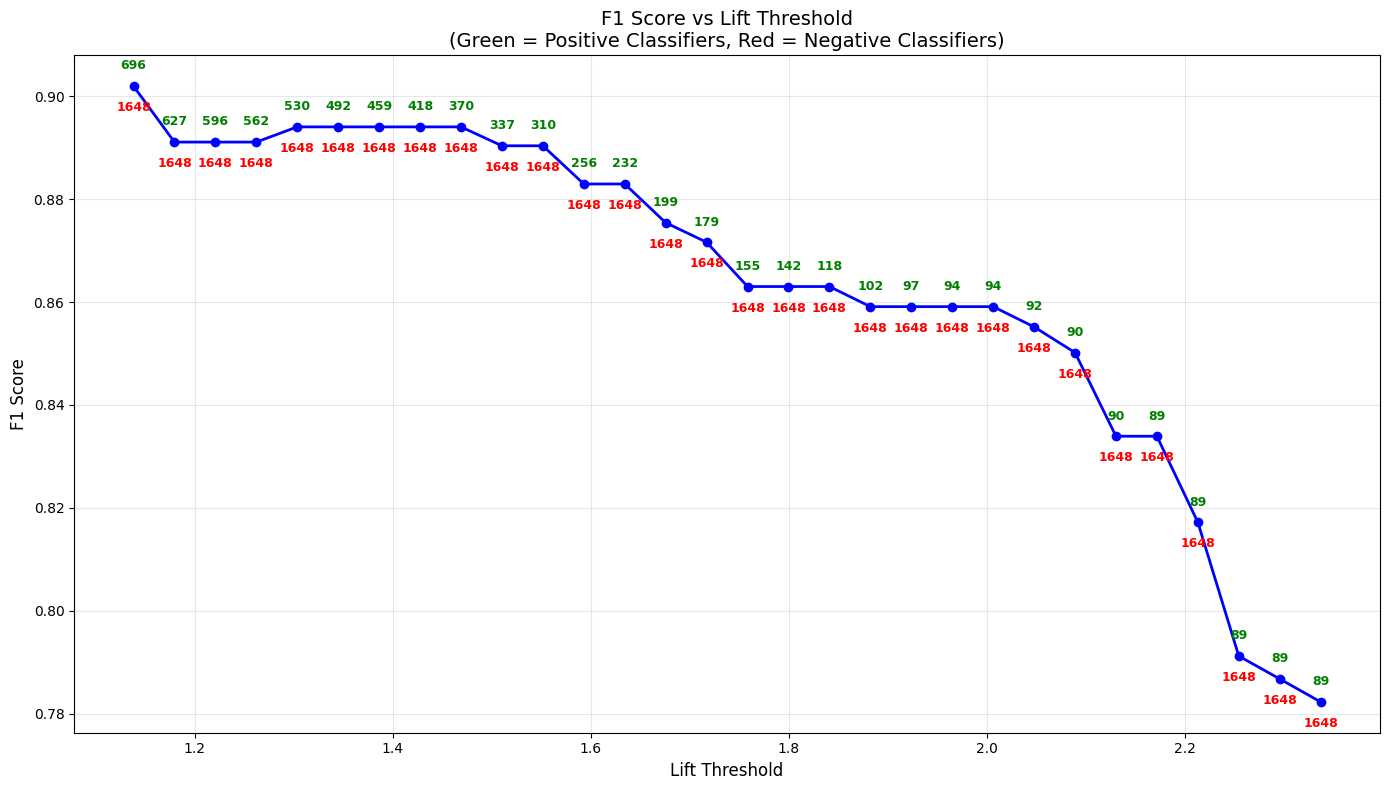


Best Lift threshold: 1.138041
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [23]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='lift',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:10<00:00, 35.74it/s]


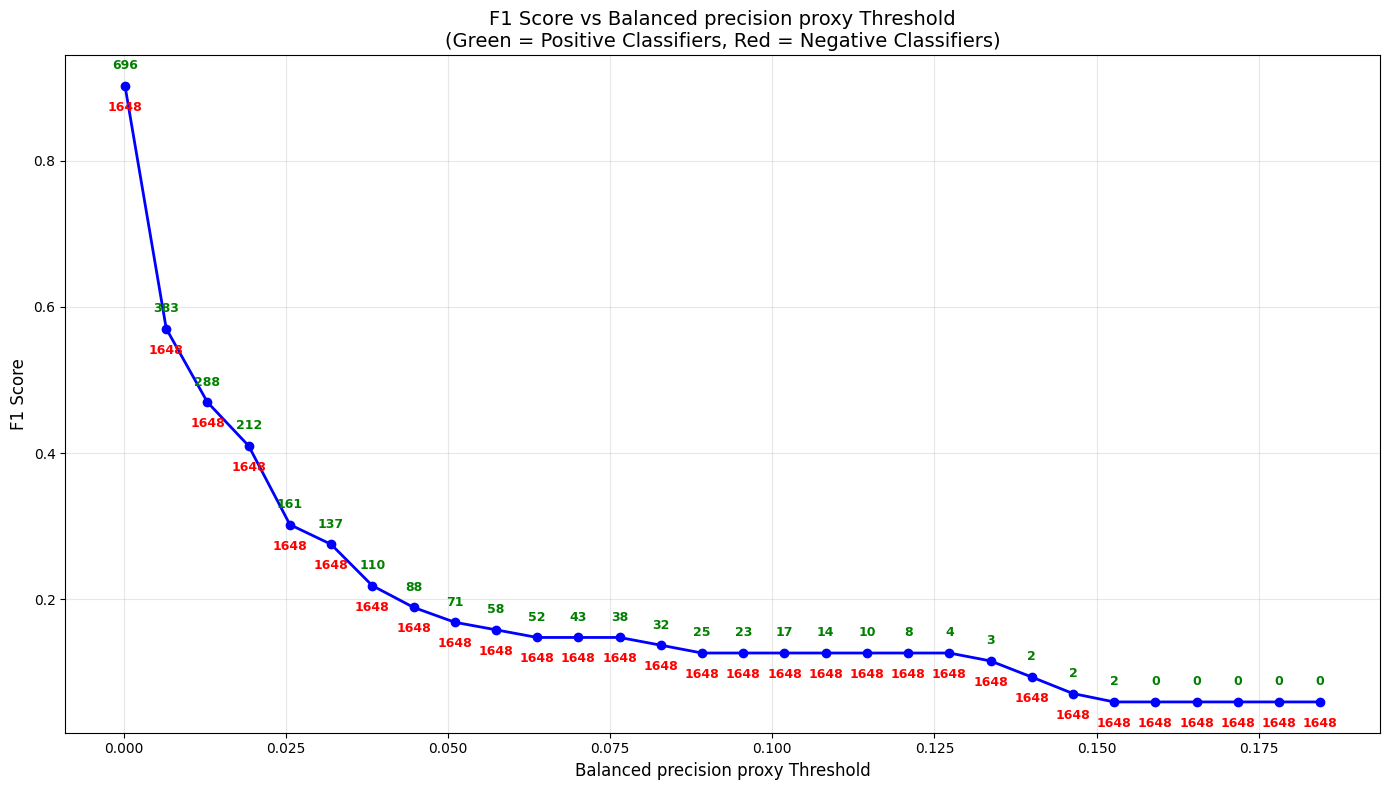


Best Balanced precision proxy threshold: 0.000172
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [24]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='balanced_precision_proxy',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:09<00:00, 40.23it/s]


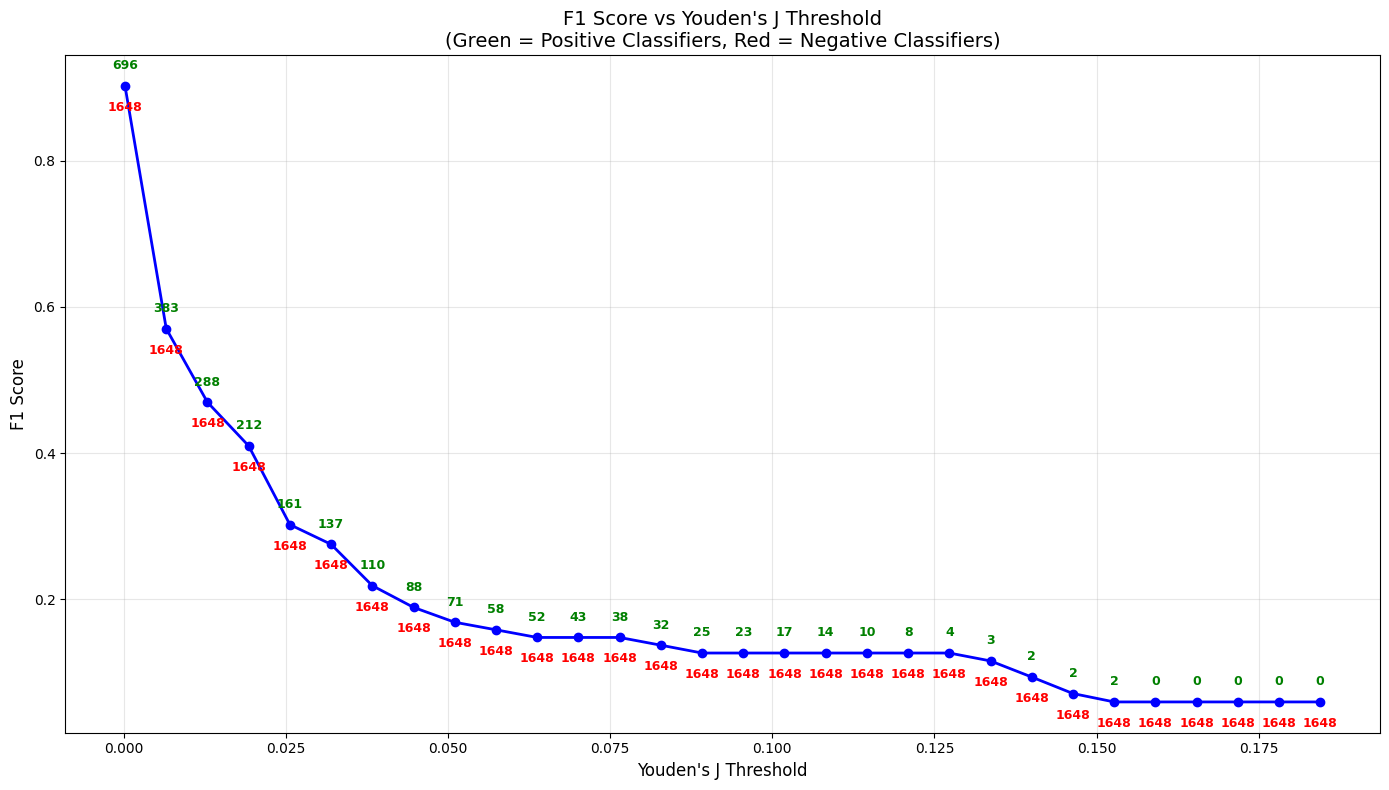


Best Youden's J threshold: 0.000172
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [25]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='youdens_j',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:10<00:00, 36.59it/s]


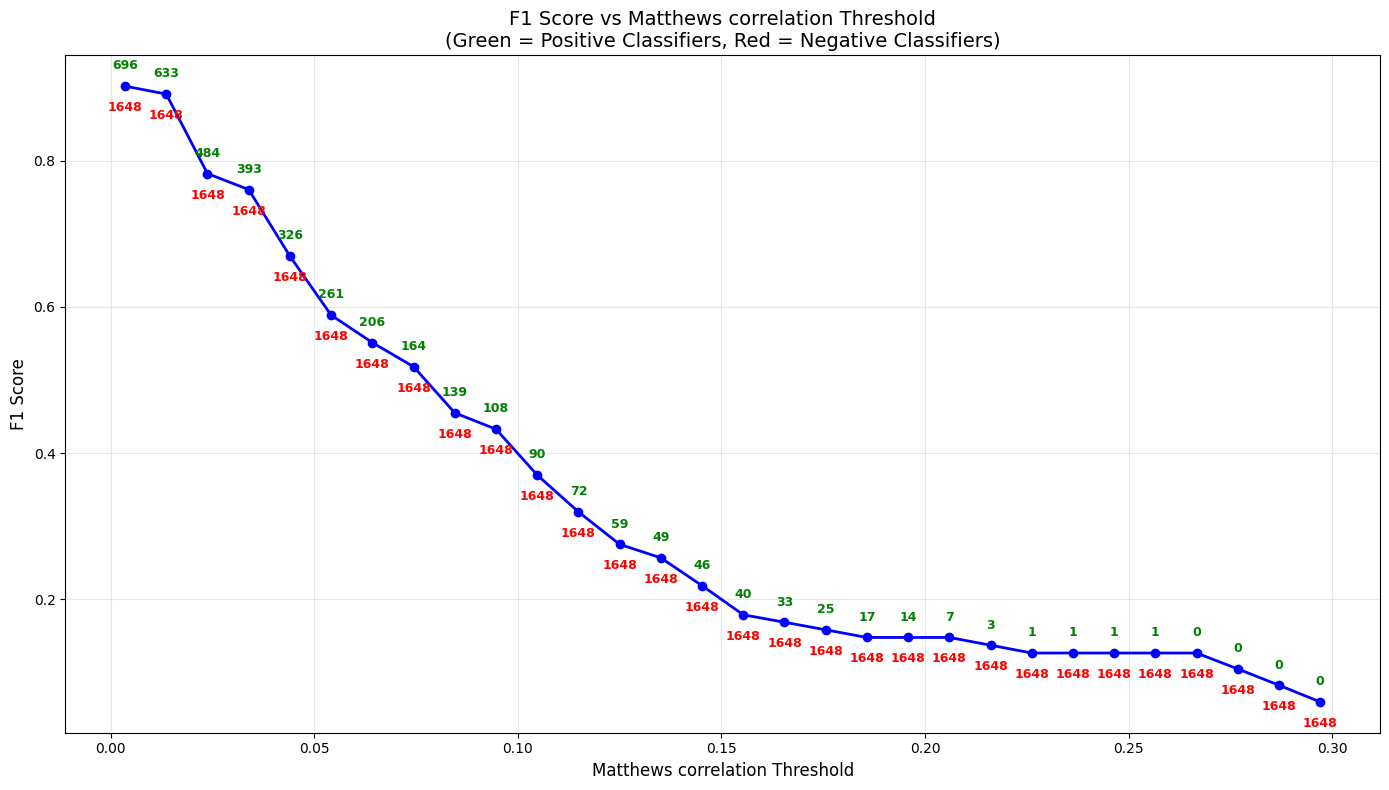


Best Matthews correlation threshold: 0.003524
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [26]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='matthews_correlation',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:10<00:00, 36.58it/s]


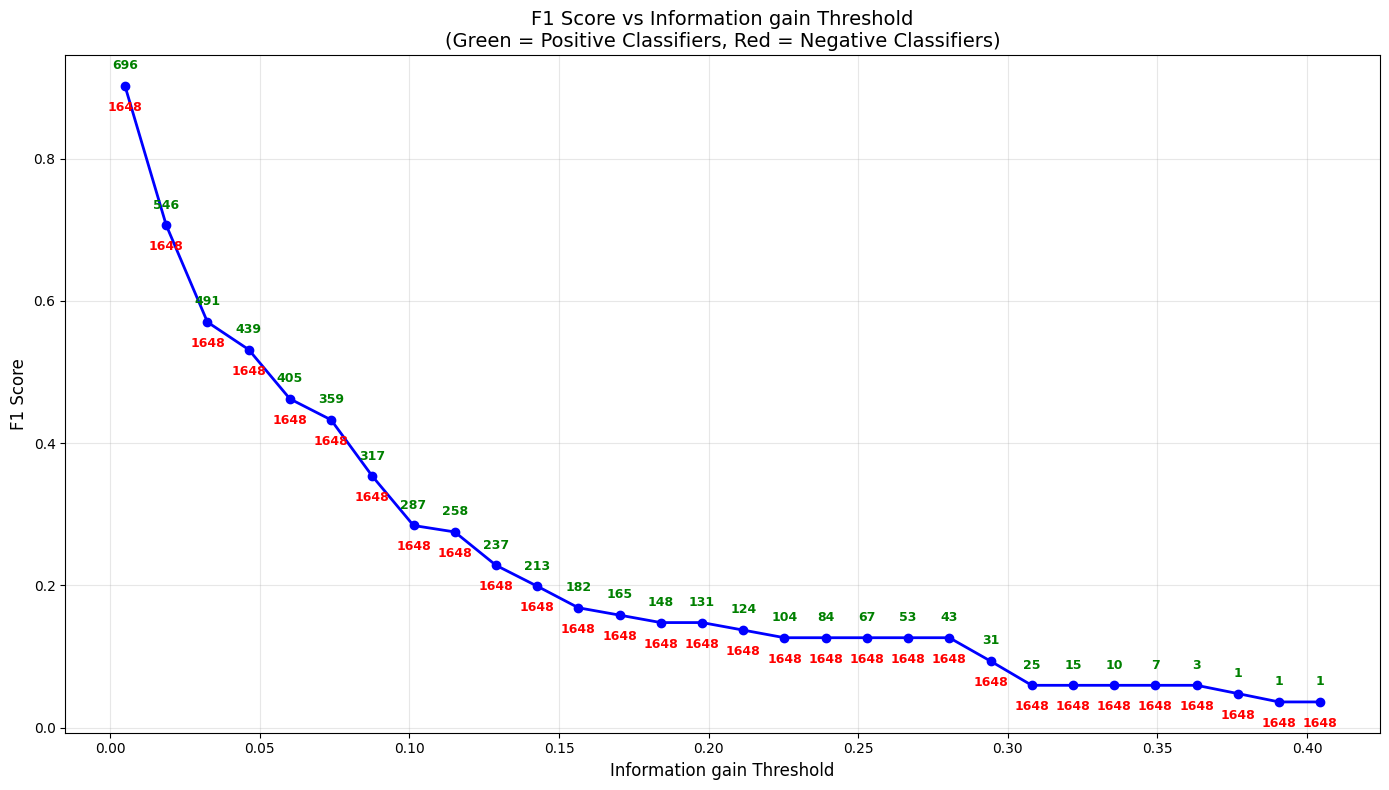


Best Information gain threshold: 0.004970
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [27]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='information_gain',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:09<00:00, 38.56it/s]


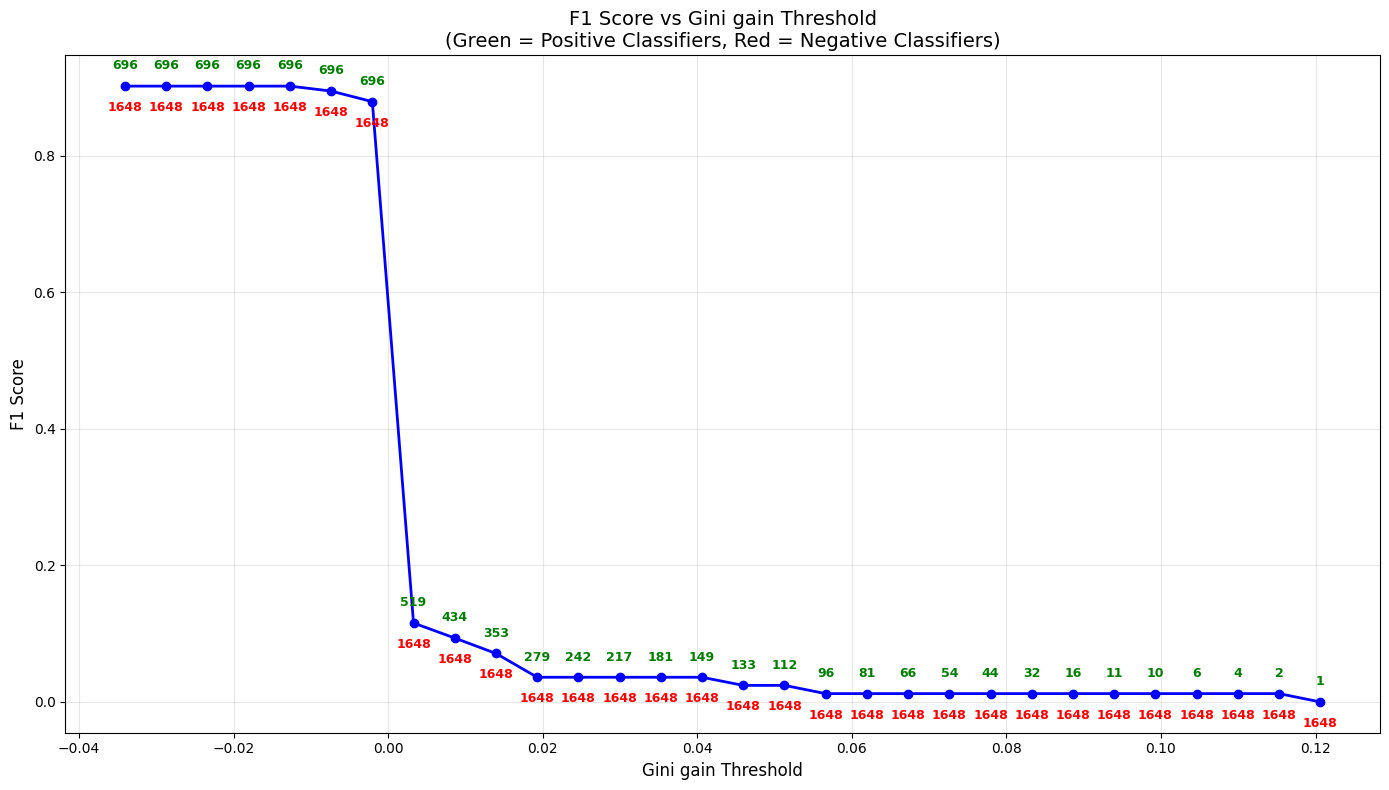


Best Gini gain threshold: -0.034042
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [28]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='gini_gain',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:09<00:00, 38.67it/s]


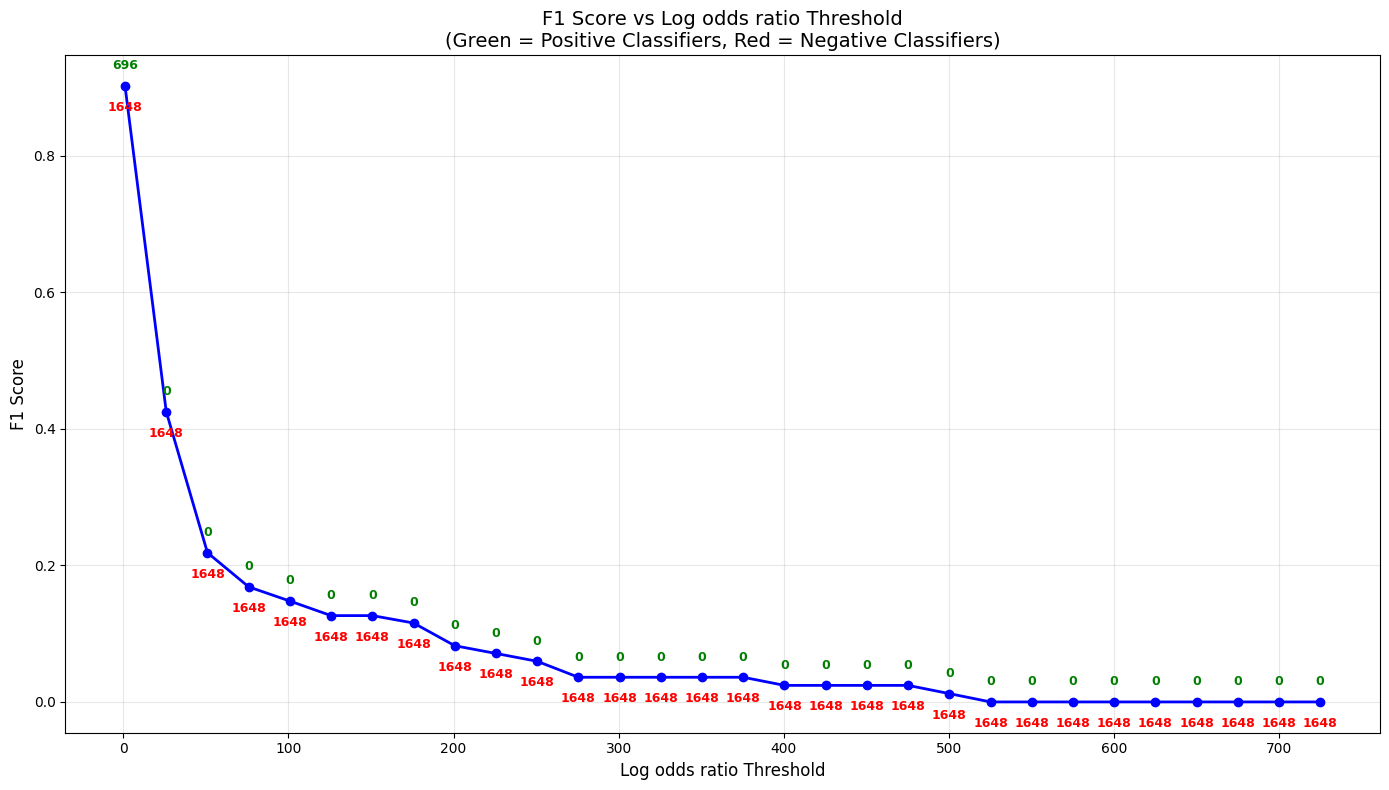


Best Log odds ratio threshold: 1.000000
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [29]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='log_odds_ratio',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:13<00:00, 28.39it/s]


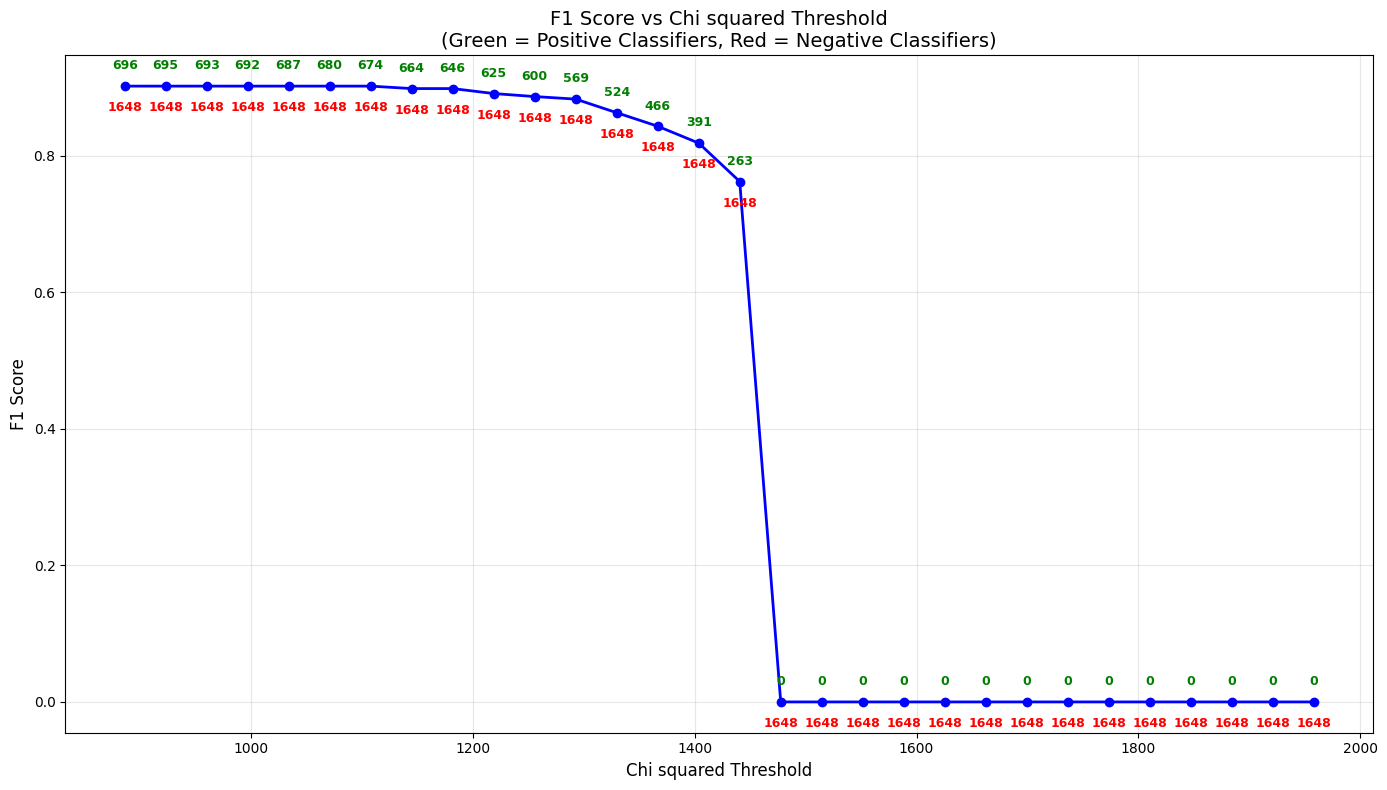


Best Chi squared threshold: 886.295379
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [30]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='chi_squared',
    n_points=N_POINTS
)

  0%|          | 0/381 [00:00<?, ?it/s]

100%|██████████| 381/381 [00:10<00:00, 37.30it/s]


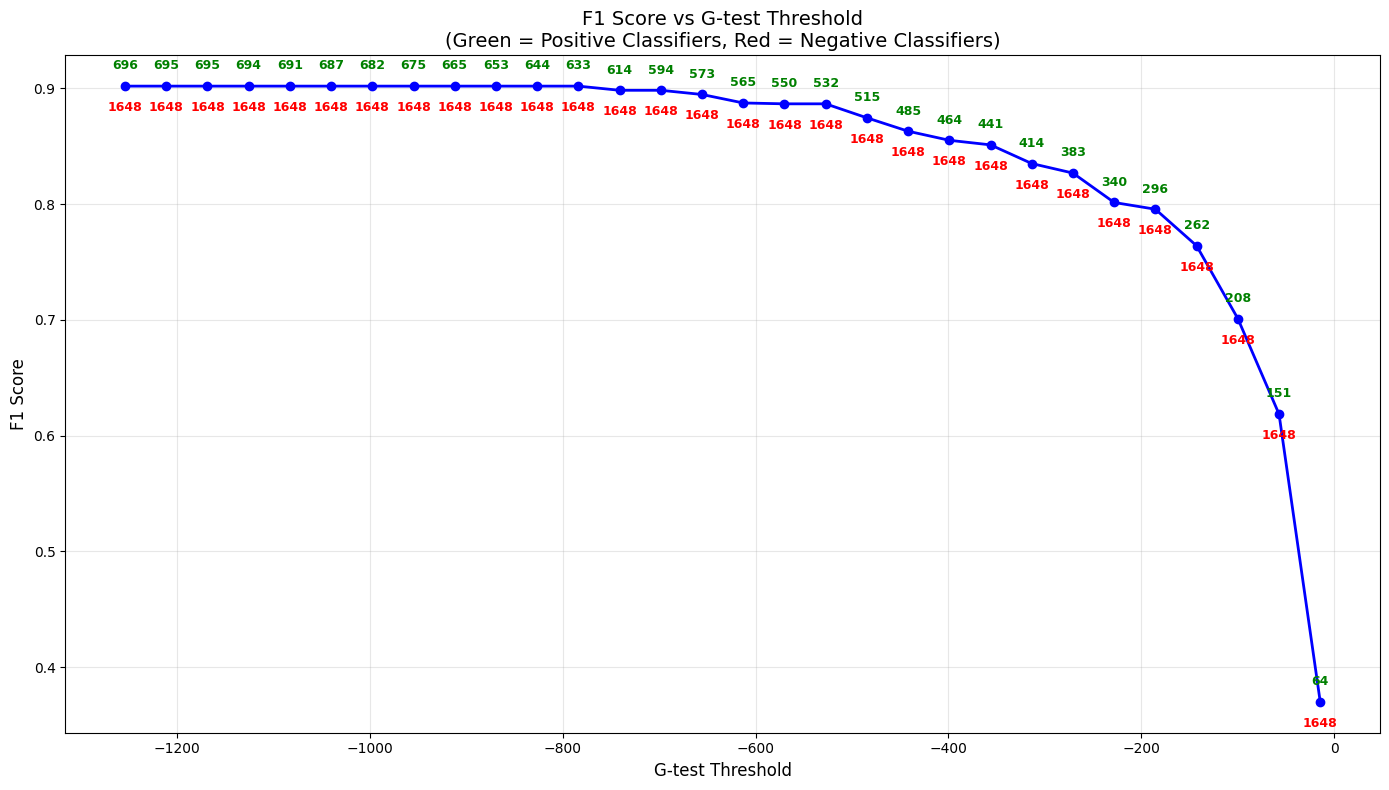


Best G-test threshold: -1253.623953
Best F1 score: 0.901961
Positive classifiers at best threshold: 696
Negative classifiers at best threshold: 1648


In [31]:
thresholds, f1_scores, pos_counts, neg_counts = plot_f1_vs_metric_threshold(
    metric_name='g_test',
    n_points=N_POINTS
)

100%|██████████| 381/381 [00:09<00:00, 41.25it/s]


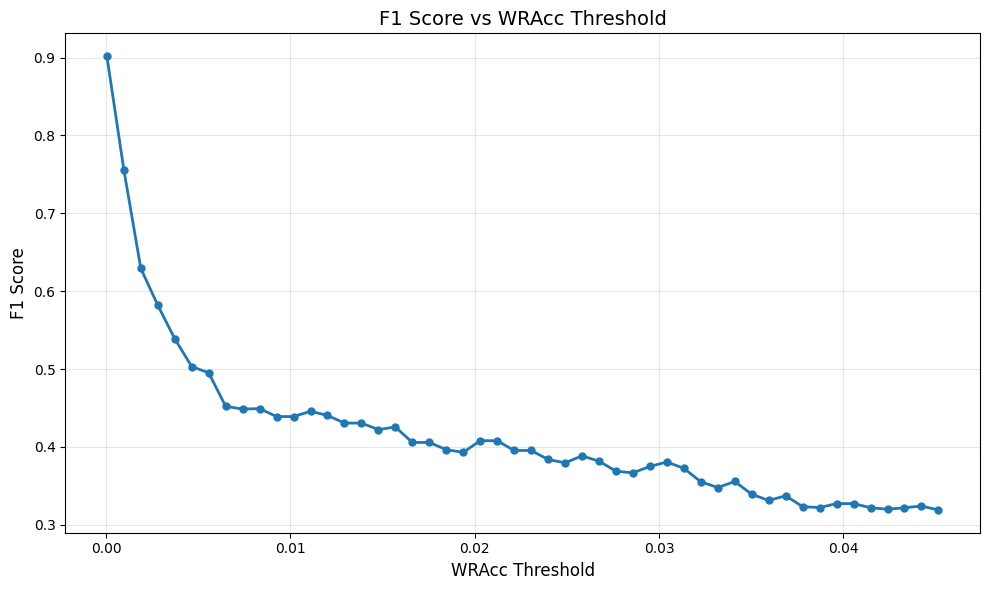


Best WRAcc threshold: 0.000042
Best F1 score: 0.901961


In [25]:
f1_scores = []

for threshold in thresholds:
    # Create classifier with WRAcc threshold
    clf = LazyFCA(
        pos_params=LazyFCA.Params(
            supporters_covered=1,
            supporter_opposer_ratio=1.0,
            wracc=threshold,  # Set WRAcc threshold
        ),
        neg_params=LazyFCA.Params(
            supporters_covered=2,
            supporter_opposer_ratio=1.7,
            wracc=threshold,  # Set WRAcc threshold
        ),
        pos_weight=1.0
    )
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    
    # Calculate F1 score
    metrics = estimate_quality(y_pred, y_test)
    f1_scores.append(metrics['F1-score'])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=5)
plt.xlabel('WRAcc Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs WRAcc Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show best threshold
best_idx = np.argmax(f1_scores)
print(f"\nBest WRAcc threshold: {thresholds[best_idx]:.6f}")
print(f"Best F1 score: {f1_scores[best_idx]:.6f}")